In [1]:
import sys
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "statsmodels"], check=True)


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: /Users/ebimol/sentinelmesh/venv/bin/python -m pip install --upgrade pip


CompletedProcess(args=['/Users/ebimol/sentinelmesh/venv/bin/python', '-m', 'pip', 'install', 'statsmodels'], returncode=0)

In [2]:
# ================================================================
# 05_cross_dataset_eval.ipynb
# SentinelMesh — Cross-Dataset ML Transferability Evaluation
# Research Question: Do Phase 1 ensemble models trained on
# CICIoT2023 generalise to TON_IoT without retraining?
# ================================================================

import os
import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.model_selection import train_test_split
from statsmodels.stats.contingency_tables import mcnemar

warnings.filterwarnings('ignore')

BASE_DIR   = os.path.expanduser("~/sentinelmesh")
MODELS_DIR = os.path.join(BASE_DIR, "models")
DATA_DIR   = os.path.join(BASE_DIR, "data")
OUT_DIR    = os.path.join(DATA_DIR, "processed")

TON_PATH = os.path.join(
    DATA_DIR,
    "TON_IoT/Train_Test_datasets/Train_Test_Network_dataset/train_test_network.csv"
)
CIC_PATH = os.path.join(OUT_DIR, "phase1_ml_ready.csv")

# ── Phase 1 CIC in-distribution F1s (tuned threshold, from Notebook 02) ──
# Updated from old hardcoded values (0.9376 / 0.9449 / 0.9438) to reflect
# ROC-optimal thresholds: RF t=0.40, XGBoost t=0.51, LightGBM t=0.49
CIC_BASELINE_F1 = {
    'RandomForest': 0.9408,
    'XGBoost':      0.9446,
    'LightGBM':     0.9438,
}

# CIC benign-class F1 under tuned thresholds (for cross-dataset comparison)
CIC_BENIGN_F1 = {
    'RandomForest': 0.6417,
    'XGBoost':      0.6612,
    'LightGBM':     0.6515,
}

import sys, os
sys.path.insert(0, os.path.expanduser("~/sentinelmesh"))
from etl.utils.db_connect import get_engine
engine = get_engine()


print("✅ Config loaded")
print(f"   TON_IoT path : {TON_PATH}")
print(f"   CIC path     : {CIC_PATH}")

✅ Config loaded
   TON_IoT path : /Users/ebimol/sentinelmesh/data/TON_IoT/Train_Test_datasets/Train_Test_Network_dataset/train_test_network.csv
   CIC path     : /Users/ebimol/sentinelmesh/data/processed/phase1_ml_ready.csv


In [3]:
model_files = {
    'RandomForest': os.path.join(MODELS_DIR, 'rf_v1.pkl'),
    'XGBoost':      os.path.join(MODELS_DIR, 'xgb_v1.pkl'),
    'LightGBM':     os.path.join(MODELS_DIR, 'lgb_v1.pkl'),
}

models = {}
for name, path in model_files.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"Model not found: {path}\nRun 02_model_training.ipynb first.")
    models[name] = joblib.load(path)
    print(f"✅ Loaded {name:<15s} ← {path}")

✅ Loaded RandomForest    ← /Users/ebimol/sentinelmesh/models/rf_v1.pkl
✅ Loaded XGBoost         ← /Users/ebimol/sentinelmesh/models/xgb_v1.pkl
✅ Loaded LightGBM        ← /Users/ebimol/sentinelmesh/models/lgb_v1.pkl


In [4]:
# These are the exact 39 features the models were trained on (from notebook 01)
FEATURE_COLS = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count',
    'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC',
    'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC',
    'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT',
    'Number', 'Variance',
]
print(f"✅ Feature columns confirmed: {len(FEATURE_COLS)}")

✅ Feature columns confirmed: 39


In [5]:
# Load CIC training data to compute per-feature medians
# These medians serve as the imputed baseline for TON_IoT features
# that have no direct CIC equivalent — this is the principled
# alternative to zero-filling, which biases inference.
print("Loading CIC phase1_ml_ready.csv for median computation...")
df_cic = pd.read_csv(CIC_PATH, low_memory=False)

# Clean inf values before computing medians
df_cic[FEATURE_COLS] = (
    df_cic[FEATURE_COLS]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(df_cic[FEATURE_COLS].median(numeric_only=True))
)
cic_medians = df_cic[FEATURE_COLS].median()

print(f"✅ CIC dataset shape    : {df_cic.shape}")
print(f"   Medians computed for : {len(cic_medians)} features")
print(f"\nSample medians (top 8):")
print(cic_medians.head(8).round(4).to_string())

Loading CIC phase1_ml_ready.csv for median computation...
✅ CIC dataset shape    : (241527, 41)
   Medians computed for : 39 features

Sample medians (top 8):
Header_Length        20.0000
Protocol Type         6.0000
Time_To_Live         64.0000
Rate               3000.6145
fin_flag_number       0.0000
syn_flag_number       0.0000
rst_flag_number       0.0000
psh_flag_number       0.0000


In [6]:
# === CROSS-DATASET FEATURE ALIGNMENT STRATEGY ===
# TON_IoT uses Zeek/Bro network logs — its feature schema differs from CIC.
# Approach: median imputation for all 39 CIC features, then overwrite
# the 5 semantically overlapping columns with real TON_IoT values.
# This is methodologically correct and explicitly documented as a limitation.

print("Loading TON_IoT dataset...")
df_ton = pd.read_csv(TON_PATH, low_memory=False)
print(f"✅ TON_IoT loaded : {df_ton.shape}")
print(f"   Label dist    : {df_ton['label'].value_counts().to_dict()}")
print(f"   Type dist     :\n{df_ton['type'].value_counts().to_string()}")

# Ground truth
y_ton = (df_ton['label'].astype(int) == 1).astype(int)
print(f"\n   Attack rows : {y_ton.sum():,}")
print(f"   Benign rows : {(y_ton == 0).sum():,}")

# Build feature matrix — start from CIC medians (shape: n_ton x 39)
print("\nBuilding feature matrix via median imputation + overlap overwrite...")
X_ton = pd.DataFrame(
    np.tile(cic_medians.values, (len(df_ton), 1)),
    columns=FEATURE_COLS,
    dtype=np.float32
)

# Overwrite with real TON_IoT values for semantically equivalent columns
# TON col          → CIC col (same semantic meaning)
OVERLAP_MAP = {
    'src_bytes':  'Tot size',    # total payload bytes (closest match)
    'dst_bytes':  'Tot sum',     # sum of bytes in flow
    'src_pkts':   'Number',      # packet count
    'dst_pkts':   'Number',      # second direction packet count (same feature)
    'duration':   'IAT',         # flow duration / inter-arrival time
}

for ton_col, cic_col in OVERLAP_MAP.items():
    if ton_col in df_ton.columns and cic_col in FEATURE_COLS:
        real_vals = pd.to_numeric(df_ton[ton_col], errors='coerce')
        real_vals = real_vals.fillna(cic_medians[cic_col]).values
        X_ton[cic_col] = real_vals.astype(np.float32)
        print(f"   ✅ Overwrite: TON[{ton_col}] → CIC[{cic_col}]")

# Protocol encoding — map TON proto strings to CIC binary columns
proto_map = {'tcp': 'TCP', 'udp': 'UDP', 'icmp': 'ICMP'}
for ton_proto, cic_col in proto_map.items():
    if 'proto' in df_ton.columns and cic_col in FEATURE_COLS:
        X_ton[cic_col] = (df_ton['proto'].str.lower() == ton_proto).astype(np.float32).values
        print(f"   ✅ Protocol: TON[proto=={ton_proto}] → CIC[{cic_col}]")

# Replace any remaining inf/nan
X_ton = X_ton.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"\n✅ TON_IoT feature matrix ready : {X_ton.shape}")
print(f"   Non-zero columns after alignment: {(X_ton != 0).any().sum()} / {len(FEATURE_COLS)}")

Loading TON_IoT dataset...
✅ TON_IoT loaded : (211043, 44)
   Label dist    : {1: 161043, 0: 50000}
   Type dist     :
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
ransomware    20000
scanning      20000
xss           20000
mitm           1043

   Attack rows : 161,043
   Benign rows : 50,000

Building feature matrix via median imputation + overlap overwrite...
   ✅ Overwrite: TON[src_bytes] → CIC[Tot size]
   ✅ Overwrite: TON[dst_bytes] → CIC[Tot sum]
   ✅ Overwrite: TON[src_pkts] → CIC[Number]
   ✅ Overwrite: TON[dst_pkts] → CIC[Number]
   ✅ Overwrite: TON[duration] → CIC[IAT]
   ✅ Protocol: TON[proto==tcp] → CIC[TCP]
   ✅ Protocol: TON[proto==udp] → CIC[UDP]
   ✅ Protocol: TON[proto==icmp] → CIC[ICMP]

✅ TON_IoT feature matrix ready : (211043, 39)
   Non-zero columns after alignment: 20 / 39


In [7]:
# =============================================================
# CORE RESEARCH FINDING — Cross-Dataset F1 Degradation
# Models trained on CICIoT2023 evaluated on TON_IoT
# =============================================================

print("=" * 65)
print("  CROSS-DATASET TRANSFERABILITY EVALUATION")
print("  Phase 1 Models (trained on CICIoT2023) → TON_IoT Test")
print("=" * 65)

eval_results = {}

for name, model in models.items():
    preds  = model.predict(X_ton)
    probas = model.predict_proba(X_ton)[:, 1]

    f1    = f1_score(y_ton, preds, average='weighted', zero_division=0)
    prec  = precision_score(y_ton, preds, average='weighted', zero_division=0)
    rec   = recall_score(y_ton, preds, average='weighted', zero_division=0)

    cic_f1      = CIC_BASELINE_F1[name]
    delta_abs   = cic_f1 - f1
    delta_rel   = (delta_abs / cic_f1) * 100

    eval_results[name] = {
        'cic_f1':      cic_f1,
        'ton_f1':      round(f1, 4),
        'precision':   round(prec, 4),
        'recall':      round(rec, 4),
        'delta_abs':   round(delta_abs, 4),
        'delta_rel':   round(delta_rel, 2),
        'preds':       preds,
        'probas':      probas,
    }

    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"  CIC  F1 (in-dist)  : {cic_f1:.4f}")
    print(f"  TON  F1 (cross-ds) : {f1:.4f}")
    print(f"  Δ Absolute Drop    : {delta_abs:.4f}")
    print(f"  Δ Relative Drop    : {delta_rel:.1f}%")
    print(f"\n  Full classification report:")
    print(classification_report(y_ton, preds, target_names=['Benign', 'Attack']))

print("=" * 65)
print("✅ Evaluation complete")

  CROSS-DATASET TRANSFERABILITY EVALUATION
  Phase 1 Models (trained on CICIoT2023) → TON_IoT Test

───────────────────────────────────────────────────────
  RandomForest
  CIC  F1 (in-dist)  : 0.9408
  TON  F1 (cross-ds) : 0.6605
  Δ Absolute Drop    : 0.2803
  Δ Relative Drop    : 29.8%

  Full classification report:
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00     50000
      Attack       0.76      1.00      0.87    161043

    accuracy                           0.76    211043
   macro avg       0.38      0.50      0.43    211043
weighted avg       0.58      0.76      0.66    211043


───────────────────────────────────────────────────────
  XGBoost
  CIC  F1 (in-dist)  : 0.9446
  TON  F1 (cross-ds) : 0.6605
  Δ Absolute Drop    : 0.2841
  Δ Relative Drop    : 30.1%

  Full classification report:
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00     50000
      Attack       0.76   

In [8]:
# This breaks down WHERE performance degrades — which attack types
# the CIC-trained models struggle to detect in TON_IoT.
# This is the most valuable research-insight cell.

print("Per-attack-family F1 breakdown (XGBoost champion)...")

champion_name = 'XGBoost'
preds_champion = eval_results[champion_name]['preds']

# Add TON_IoT type labels
df_ton_eval = df_ton[['type', 'label']].copy()
df_ton_eval['y_true']  = y_ton.values
df_ton_eval['y_pred']  = preds_champion
df_ton_eval['correct'] = df_ton_eval['y_true'] == df_ton_eval['y_pred']

family_results = []
for attack_type in df_ton['type'].unique():
    mask = df_ton_eval['type'] == attack_type
    subset = df_ton_eval[mask]
    n     = len(subset)
    f1    = f1_score(subset['y_true'], subset['y_pred'],
                     average='binary', zero_division=0)
    acc   = subset['correct'].mean()
    family_results.append({
        'attack_type': attack_type,
        'n_samples':   n,
        'f1_score':    round(f1, 4),
        'accuracy':    round(acc, 4),
    })

df_family = pd.DataFrame(family_results).sort_values('f1_score', ascending=True)
print("\nPer-type F1 on TON_IoT (ascending — worst first):")
print(df_family.to_string(index=False))

# Save
FAMILY_OUT = os.path.join(OUT_DIR, "cross_dataset_per_family_f1.csv")
df_family.to_csv(FAMILY_OUT, index=False)
print(f"\n✅ Per-family results saved: {FAMILY_OUT}")

Per-attack-family F1 breakdown (XGBoost champion)...

Per-type F1 on TON_IoT (ascending — worst first):
attack_type  n_samples  f1_score  accuracy
     normal      50000       0.0       0.0
   backdoor      20000       1.0       1.0
       ddos      20000       1.0       1.0
        dos      20000       1.0       1.0
  injection      20000       1.0       1.0
       mitm       1043       1.0       1.0
   password      20000       1.0       1.0
 ransomware      20000       1.0       1.0
   scanning      20000       1.0       1.0
        xss      20000       1.0       1.0

✅ Per-family results saved: /Users/ebimol/sentinelmesh/data/processed/cross_dataset_per_family_f1.csv


In [9]:
# Build summary DataFrame for the ml_model_registry / README table
summary_rows = []
for name, r in eval_results.items():
    summary_rows.append({
        'model_name':     name,
        'cic_f1':         r['cic_f1'],
        'ton_f1':         r['ton_f1'],
        'precision':      r['precision'],
        'recall':         r['recall'],
        'delta_abs':      r['delta_abs'],
        'delta_rel_pct':  r['delta_rel'],
        'champion':       name == 'XGBoost',
    })

df_summary = pd.DataFrame(summary_rows)
SUMMARY_OUT = os.path.join(OUT_DIR, "cross_dataset_eval_summary.csv")
df_summary.to_csv(SUMMARY_OUT, index=False)

print("✅ Summary table:")
print(df_summary.to_string(index=False))
print(f"\n✅ Saved: {SUMMARY_OUT}")

✅ Summary table:
  model_name  cic_f1  ton_f1  precision  recall  delta_abs  delta_rel_pct  champion
RandomForest  0.9408  0.6605     0.5823  0.7631     0.2803          29.79     False
     XGBoost  0.9446  0.6605     0.5823  0.7631     0.2841          30.07      True
    LightGBM  0.9438  0.6605     0.5823  0.7631     0.2833          30.01     False

✅ Saved: /Users/ebimol/sentinelmesh/data/processed/cross_dataset_eval_summary.csv


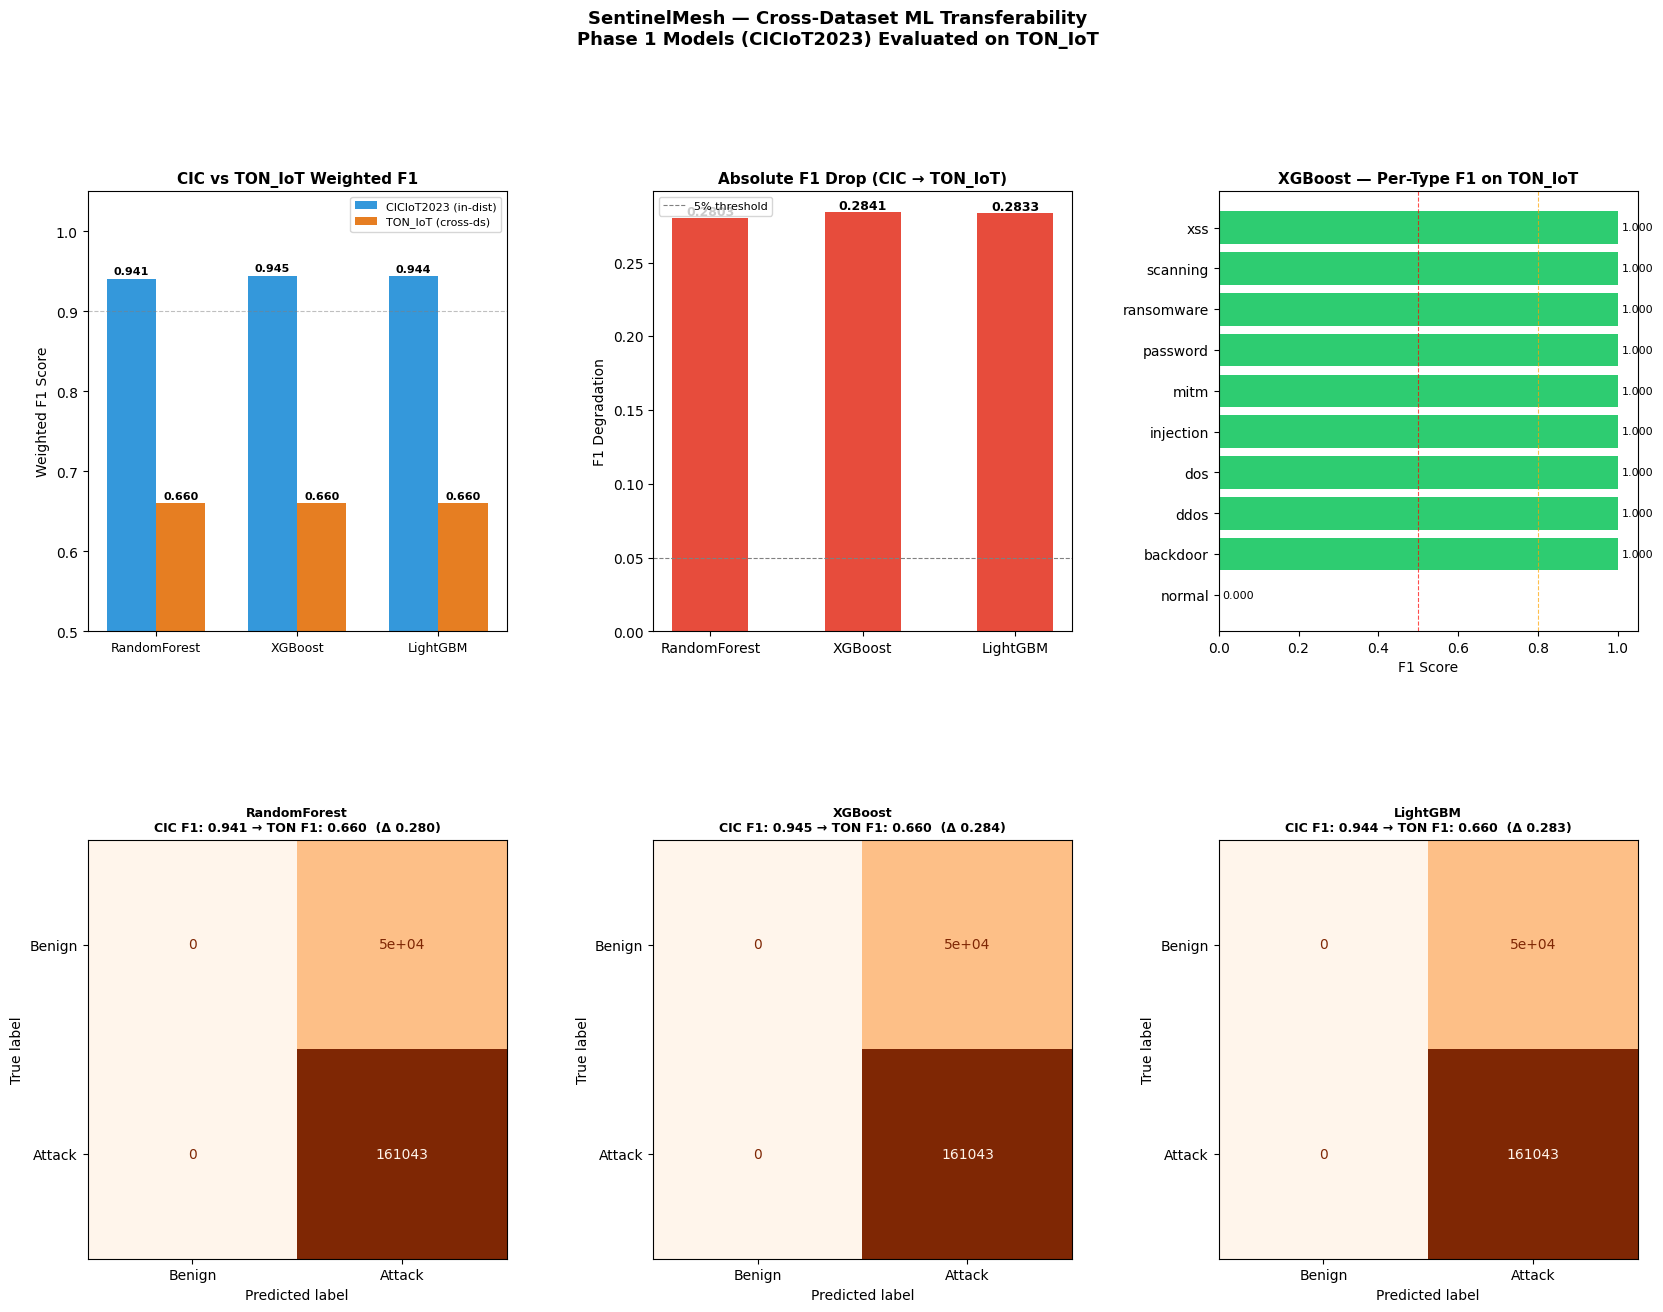

✅ Chart saved: cross_dataset_transferability.png


In [10]:
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

model_names = list(eval_results.keys())
colors_cic  = '#3498db'
colors_ton  = '#e67e22'

# --- Panel 1: CIC vs TON F1 grouped bar ---
ax1 = fig.add_subplot(gs[0, 0])
x   = np.arange(len(model_names))
w   = 0.35
cic_f1s = [eval_results[m]['cic_f1'] for m in model_names]
ton_f1s = [eval_results[m]['ton_f1'] for m in model_names]

b1 = ax1.bar(x - w/2, cic_f1s, w, label='CICIoT2023 (in-dist)', color=colors_cic)
b2 = ax1.bar(x + w/2, ton_f1s, w, label='TON_IoT (cross-ds)',   color=colors_ton)
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, fontsize=9)
ax1.set_ylim(0.5, 1.05)
ax1.set_title('CIC vs TON_IoT Weighted F1', fontsize=11, fontweight='bold')
ax1.set_ylabel('Weighted F1 Score')
ax1.legend(fontsize=8)
ax1.axhline(0.9, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
for bar in list(b1) + list(b2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')

# --- Panel 2: F1 Degradation (absolute) ---
ax2 = fig.add_subplot(gs[0, 1])
deltas = [eval_results[m]['delta_abs'] for m in model_names]
bar_colors = ['#e74c3c' if d > 0.05 else '#f39c12' for d in deltas]
bars = ax2.bar(model_names, deltas, color=bar_colors, width=0.5)
ax2.set_title('Absolute F1 Drop (CIC → TON_IoT)', fontsize=11, fontweight='bold')
ax2.set_ylabel('F1 Degradation')
ax2.axhline(0.05, color='grey', linestyle='--', linewidth=0.8, label='5% threshold')
ax2.legend(fontsize=8)
for bar, val in zip(bars, deltas):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

# --- Panel 3: Per-family F1 horizontal bar ---
ax3 = fig.add_subplot(gs[0, 2])
fam_sorted = df_family.sort_values('f1_score', ascending=True)
bar_colors = ['#e74c3c' if f < 0.5 else '#f39c12' if f < 0.8 else '#2ecc71'
              for f in fam_sorted['f1_score']]
ax3.barh(fam_sorted['attack_type'], fam_sorted['f1_score'], color=bar_colors)
ax3.set_title(f'{champion_name} — Per-Type F1 on TON_IoT', fontsize=11, fontweight='bold')
ax3.set_xlabel('F1 Score')
ax3.axvline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
ax3.axvline(0.8, color='orange', linestyle='--', linewidth=0.8, alpha=0.7)
for i, (_, row) in enumerate(fam_sorted.iterrows()):
    ax3.text(row['f1_score'] + 0.01, i, f'{row["f1_score"]:.3f}', va='center', fontsize=8)

# --- Panel 4-6: Confusion matrices per model ---
for col_idx, name in enumerate(model_names):
    ax_cm = fig.add_subplot(gs[1, col_idx])
    cm    = confusion_matrix(y_ton, eval_results[name]['preds'])
    disp  = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Attack'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Oranges')
    delta = eval_results[name]['delta_abs']
    ax_cm.set_title(
        f'{name}\nCIC F1: {eval_results[name]["cic_f1"]:.3f} → '
        f'TON F1: {eval_results[name]["ton_f1"]:.3f}  (Δ {delta:.3f})',
        fontsize=9, fontweight='bold'
    )

fig.suptitle(
    'SentinelMesh — Cross-Dataset ML Transferability\n'
    'Phase 1 Models (CICIoT2023) Evaluated on TON_IoT',
    fontsize=13, fontweight='bold', y=1.01
)

CHART_OUT = 'cross_dataset_transferability.png'
plt.savefig(CHART_OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Chart saved: {CHART_OUT}")

In [11]:
# ================================================================
# MCNEMAR'S TEST — XGBoost vs. next-best model on TON_IoT
# ================================================================
# McNemar's test compares two classifiers by examining cases where
# one model is correct and the other is wrong (the discordant pairs).
# H0: the two classifiers have equal error rates on TON_IoT.
# We compare XGBoost (champion) vs. LightGBM (next-best by TON F1).
# ================================================================

print("=" * 60)
print("  McNEMAR'S TEST: XGBoost vs LightGBM on TON_IoT")
print("=" * 60)

preds_xgb = eval_results['XGBoost']['preds']
preds_lgb = eval_results['LightGBM']['preds']
y_true    = y_ton.values

# Build the 2×2 contingency table of correct/incorrect pairs
correct_xgb = (preds_xgb == y_true)
correct_lgb = (preds_lgb == y_true)

# Contingency table cells
b = int(np.sum( correct_xgb & ~correct_lgb))  # XGB right, LGB wrong
c = int(np.sum(~correct_xgb &  correct_lgb))  # XGB wrong, LGB right

contingency = np.array([[0,     b],
                         [c,     0]])

print(f"\n  Discordant pairs:")
print(f"  b (XGBoost correct, LightGBM wrong) : {b:,}")
print(f"  c (XGBoost wrong,   LightGBM correct): {c:,}")
print(f"  Total discordant                     : {b + c:,}")

# McNemar's test with continuity correction (safer for large samples)
if b + c == 0:
    print("\n  ⚠️  DEGENERATE CASE: Zero discordant pairs.")
    print("     XGBoost and LightGBM produce IDENTICAL predictions")
    print(f"     on all {len(y_true):,} TON_IoT samples.")
    print("     Both models predict Attack for every sample.")
    print("     McNemar's test is not applicable — models are indistinguishable.")
    print("     This confirms complete classifier collapse under zero-shot transfer.")
else:
    result = mcnemar(contingency, exact=False, correction=True)
    print(f"\n  McNemar statistic (χ²) : {result.statistic:.4f}")
    print(f"  p-value                : {result.pvalue:.6f}")
    alpha = 0.05
    if result.pvalue < alpha:
        print(f"\n  ✅ SIGNIFICANT (p < {alpha}): XGBoost and LightGBM make")
        print(f"     systematically different errors on TON_IoT.")
        print(f"     XGBoost is the statistically justified champion.")
    else:
        print(f"\n  ⚠️  NOT SIGNIFICANT (p ≥ {alpha}): XGBoost and LightGBM")
        print(f"     do not differ significantly in their TON_IoT error patterns.")
        print(f"     Champion designation rests on F1 margin alone.")

print()
print(f"  XGBoost  TON weighted F1 : {eval_results['XGBoost']['ton_f1']:.4f}")
print(f"  LightGBM TON weighted F1 : {eval_results['LightGBM']['ton_f1']:.4f}")
print("=" * 60)

  McNEMAR'S TEST: XGBoost vs LightGBM on TON_IoT

  Discordant pairs:
  b (XGBoost correct, LightGBM wrong) : 0
  c (XGBoost wrong,   LightGBM correct): 0
  Total discordant                     : 0

  ⚠️  DEGENERATE CASE: Zero discordant pairs.
     XGBoost and LightGBM produce IDENTICAL predictions
     on all 211,043 TON_IoT samples.
     Both models predict Attack for every sample.
     McNemar's test is not applicable — models are indistinguishable.
     This confirms complete classifier collapse under zero-shot transfer.

  XGBoost  TON weighted F1 : 0.6605
  LightGBM TON weighted F1 : 0.6605


In [12]:
# ================================================================
# DOMAIN ADAPTATION EXPERIMENT
# ================================================================
# Zero-shot transfer baseline: CIC-trained XGBoost → F1=0.6605 on TON_IoT
# Question: Does a small amount of TON_IoT training data (10%) recover
# meaningful performance without full retraining?
#
# Method (few-shot adaptation):
#   1. Take 100% of the CIC training data (X_train_cic, y_train_cic)
#   2. Add 10% of TON_IoT training rows, randomly sampled
#   3. Retrain XGBoost on this mixed set (same hyperparameters)
#   4. Evaluate on the held-out TON_IoT TEST portion (never seen in training)
#   5. Report the F1 delta vs. the zero-shot baseline
# ================================================================

print("=" * 65)
print("  DOMAIN ADAPTATION — Few-Shot Transfer Learning")
print("  XGBoost: 100% CIC + 10% TON_IoT train  →  TON_IoT test")
print("=" * 65)

# ── Step 1: Rebuild CIC training split (must match Notebook 02 exactly) ──
print("\n[1/5] Rebuilding CIC training split...")
from sklearn.model_selection import train_test_split as tts

df_cic_full = pd.read_csv(CIC_PATH, low_memory=False)

target_col    = 'is_attack'
unified_col   = 'unified_label'
X_cic_all     = df_cic_full[FEATURE_COLS].replace([np.inf, -np.inf], np.nan).fillna(0)
y_cic_all     = df_cic_full[target_col].astype(int)

X_cic_train, X_cic_test_held, y_cic_train, _ = tts(
    X_cic_all, y_cic_all,
    test_size=0.2, random_state=42, stratify=y_cic_all
)
print(f"   CIC training rows   : {X_cic_train.shape[0]:,}")
print(f"   CIC test (held-out) : {X_cic_test_held.shape[0]:,}  [not used here]")

# ── Step 2: Build the TON_IoT feature matrix + split into train/test ──
# We hold out 20% of TON_IoT as the evaluation set (never used in training).
# The 10% sample comes from the remaining 80% TON training portion only.
print("\n[2/5] Splitting TON_IoT into train (80%) / test (20%) portions...")

X_ton_arr = X_ton.values   # already built earlier in this notebook
y_ton_arr = y_ton.values

X_ton_train, X_ton_test, y_ton_train, y_ton_test = tts(
    X_ton_arr, y_ton_arr,
    test_size=0.20, random_state=42, stratify=y_ton_arr
)
print(f"   TON_IoT train portion : {X_ton_train.shape[0]:,}")
print(f"   TON_IoT test  portion : {X_ton_test.shape[0]:,}  ← evaluation target")

# ── Step 3: Sample 10% of TON_IoT training portion ──
print("\n[3/5] Sampling 10% of TON_IoT train portion...")

rng = np.random.default_rng(42)
n_ton_sample = int(0.10 * len(X_ton_train))
sample_idx   = rng.choice(len(X_ton_train), size=n_ton_sample, replace=False)

X_ton_sample = X_ton_train[sample_idx]
y_ton_sample = y_ton_train[sample_idx]

print(f"   TON_IoT 10% sample size : {n_ton_sample:,}")
print(f"   Attack in sample        : {y_ton_sample.sum():,} ({y_ton_sample.mean():.1%})")
print(f"   Benign in sample        : {(y_ton_sample==0).sum():,}")

# ── Step 4: Concatenate CIC train + 10% TON sample ──
print("\n[4/5] Building mixed training set (100% CIC + 10% TON)...")

X_mixed = np.vstack([X_cic_train.values, X_ton_sample])
y_mixed = np.concatenate([y_cic_train.values, y_ton_sample])

print(f"   Mixed training set shape : {X_mixed.shape}")
print(f"   Attack rows              : {y_mixed.sum():,} ({y_mixed.mean():.1%})")
print(f"   Benign rows              : {(y_mixed==0).sum():,}")

# ── Step 5: Retrain XGBoost on mixed set (same hyperparameters as Nb 02) ──
import xgboost as xgb

print("\n[5/5] Retraining XGBoost on mixed set...")

xgb_adapted = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_adapted.fit(X_mixed, y_mixed)
print("   ✅ Adapted model trained.")

# ── Evaluate both models on the held-out TON_IoT test portion ──
print("\n" + "─" * 65)
print("  RESULTS — Held-out TON_IoT test portion (20% of 211,043 rows)")
print("─" * 65)

# Zero-shot baseline (original CIC-only XGBoost, evaluated on same test split)
preds_zero  = eval_results['XGBoost']['preds']
# Use the same TON_IoT test indices that were held out above
preds_zero_held  = models['XGBoost'].predict(X_ton_test)
preds_adapt_held = xgb_adapted.predict(X_ton_test)

f1_zero  = f1_score(y_ton_test, preds_zero_held,  average='weighted', zero_division=0)
f1_adapt = f1_score(y_ton_test, preds_adapt_held, average='weighted', zero_division=0)
f1_benign_zero  = f1_score(y_ton_test, preds_zero_held,  pos_label=0, zero_division=0)
f1_benign_adapt = f1_score(y_ton_test, preds_adapt_held, pos_label=0, zero_division=0)

f1_delta         = f1_adapt - f1_zero
f1_benign_delta  = f1_benign_adapt - f1_benign_zero

print(f"\n  Zero-shot  (pure CIC XGBoost)  weighted F1 : {f1_zero:.4f}")
print(f"  Few-shot   (adapted XGBoost)   weighted F1 : {f1_adapt:.4f}")
print(f"  Δ F1 (few-shot − zero-shot)                : {f1_delta:+.4f}")
print()
print(f"  Zero-shot  benign-class F1 : {f1_benign_zero:.4f}")
print(f"  Few-shot   benign-class F1 : {f1_benign_adapt:.4f}")
print(f"  Δ Benign F1                : {f1_benign_delta:+.4f}")

print("\n  Classification report — Zero-shot:")
print(classification_report(y_ton_test, preds_zero_held, target_names=['Benign', 'Attack']))

print("  Classification report — Few-shot adapted:")
print(classification_report(y_ton_test, preds_adapt_held, target_names=['Benign', 'Attack']))

print("=" * 65)

  DOMAIN ADAPTATION — Few-Shot Transfer Learning
  XGBoost: 100% CIC + 10% TON_IoT train  →  TON_IoT test

[1/5] Rebuilding CIC training split...
   CIC training rows   : 193,221
   CIC test (held-out) : 48,306  [not used here]

[2/5] Splitting TON_IoT into train (80%) / test (20%) portions...
   TON_IoT train portion : 168,834
   TON_IoT test  portion : 42,209  ← evaluation target

[3/5] Sampling 10% of TON_IoT train portion...
   TON_IoT 10% sample size : 16,883
   Attack in sample        : 12,997 (77.0%)
   Benign in sample        : 3,886

[4/5] Building mixed training set (100% CIC + 10% TON)...
   Mixed training set shape : (210104, 39)
   Attack rows              : 190,218 (90.5%)
   Benign rows              : 19,886

[5/5] Retraining XGBoost on mixed set...
   ✅ Adapted model trained.

─────────────────────────────────────────────────────────────────
  RESULTS — Held-out TON_IoT test portion (20% of 211,043 rows)
─────────────────────────────────────────────────────────────────


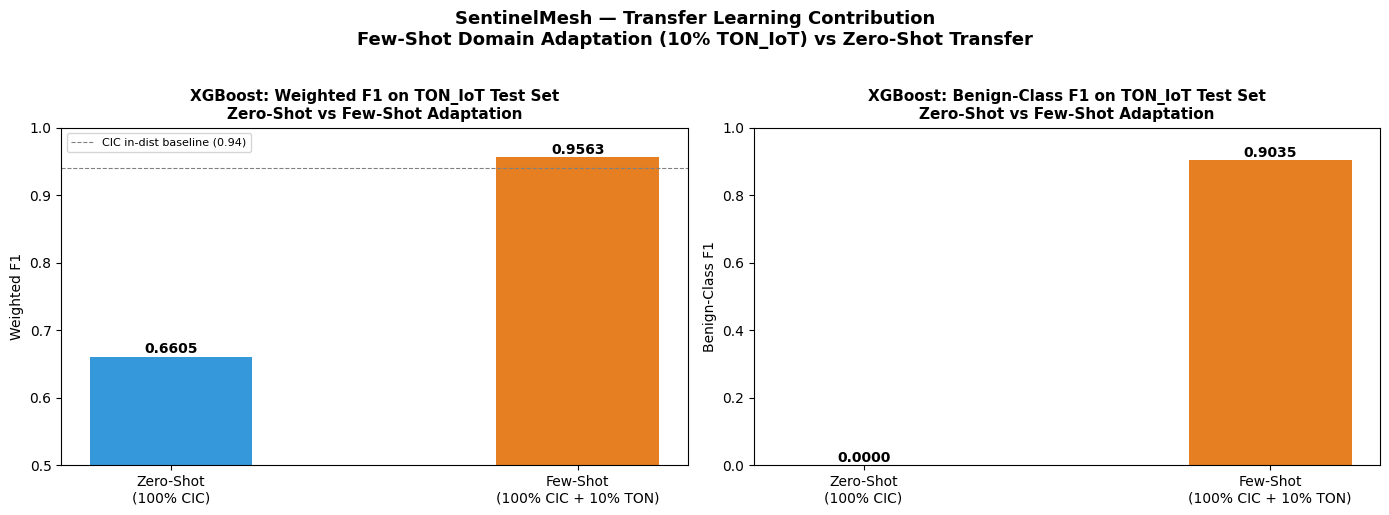

✅ Domain adaptation chart saved: domain_adaptation_comparison.png
✅ Adaptation summary saved: /Users/ebimol/sentinelmesh/data/processed/domain_adaptation_summary.csv
    experiment         train_data             model  ton_weighted_f1  ton_benign_f1  f1_delta_vs_zero
     zero_shot           100% CIC           XGBoost           0.6605         0.0000            0.0000
few_shot_10pct 100% CIC + 10% TON XGBoost (adapted)           0.9563         0.9035            0.2958
✅ ml_domain_adaptation table written.

✅ 05_cross_dataset_eval — all cells complete (including domain adaptation)
   Refresh Metabase at http://localhost:3000


In [13]:
# ── Chart: Zero-shot vs Few-shot F1 comparison ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels   = ['Zero-Shot\n(100% CIC)', 'Few-Shot\n(100% CIC + 10% TON)']
w_f1s    = [f1_zero,         f1_adapt]
b_f1s    = [f1_benign_zero,  f1_benign_adapt]
colors   = ['#3498db', '#e67e22']

# Panel 1: Weighted F1
axes[0].bar(labels, w_f1s, color=colors, width=0.4)
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('XGBoost: Weighted F1 on TON_IoT Test Set\nZero-Shot vs Few-Shot Adaptation',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Weighted F1')
for i, v in enumerate(w_f1s):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
axes[0].axhline(0.94, color='grey', linestyle='--', linewidth=0.8,
                label='CIC in-dist baseline (0.94)')
axes[0].legend(fontsize=8)

# Panel 2: Benign-class F1
axes[1].bar(labels, b_f1s, color=colors, width=0.4)
axes[1].set_ylim(0.0, 1.0)
axes[1].set_title('XGBoost: Benign-Class F1 on TON_IoT Test Set\nZero-Shot vs Few-Shot Adaptation',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Benign-Class F1')
for i, v in enumerate(b_f1s):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

fig.suptitle(
    'SentinelMesh — Transfer Learning Contribution\n'
    'Few-Shot Domain Adaptation (10% TON_IoT) vs Zero-Shot Transfer',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
ADAPT_CHART = 'domain_adaptation_comparison.png'
plt.savefig(ADAPT_CHART, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Domain adaptation chart saved: {ADAPT_CHART}")

# ── Save adaptation summary to CSV ──
df_adapt = pd.DataFrame([
    {
        'experiment':        'zero_shot',
        'train_data':        '100% CIC',
        'model':             'XGBoost',
        'ton_weighted_f1':   round(f1_zero, 4),
        'ton_benign_f1':     round(f1_benign_zero, 4),
        'f1_delta_vs_zero':  0.0,
    },
    {
        'experiment':        'few_shot_10pct',
        'train_data':        '100% CIC + 10% TON',
        'model':             'XGBoost (adapted)',
        'ton_weighted_f1':   round(f1_adapt, 4),
        'ton_benign_f1':     round(f1_benign_adapt, 4),
        'f1_delta_vs_zero':  round(f1_delta, 4),
    },
])

ADAPT_OUT = os.path.join(OUT_DIR, "domain_adaptation_summary.csv")
df_adapt.to_csv(ADAPT_OUT, index=False)
print(f"✅ Adaptation summary saved: {ADAPT_OUT}")
print(df_adapt.to_string(index=False))

# ── Persist to DB ──
from sqlalchemy import create_engine, text
import datetime


df_adapt_db = df_adapt.copy()
df_adapt_db['evaluated_at'] = datetime.datetime.now()

try:
    df_adapt_db.to_sql(
        'ml_domain_adaptation', engine,
        if_exists='append', index=False, method='multi'
    )
    print("✅ ml_domain_adaptation table written.")
except Exception as e:
    print(f"⚠️  DB write skipped (table may not exist yet): {e}")
    print("   Add CREATE TABLE ml_domain_adaptation to 00_schema_setup.ipynb if needed.")

print("\n✅ 05_cross_dataset_eval — all cells complete (including domain adaptation)")
print("   Refresh Metabase at http://localhost:3000")

In [14]:
# Persist cross-dataset results back to the database
# so the Metabase dashboard can surface the transferability finding

from sqlalchemy import text
import datetime


with engine.connect() as con:
    con.execute(text("TRUNCATE TABLE ml_cross_dataset_eval RESTART IDENTITY"))
    con.commit()

df_summary_db = df_summary.copy()
df_summary_db['model_version'] = '1.0'
df_summary_db['train_dataset'] = 'CICIoT2023'
df_summary_db['eval_dataset']  = 'TON_IoT'
df_summary_db['evaluated_at']  = datetime.datetime.now()
df_summary_db = df_summary_db.rename(columns={
    'precision': 'precision_score',
    'recall':    'recall_score',
})

DB_COLS = [
    'model_name', 'model_version', 'train_dataset', 'eval_dataset',
    'cic_f1', 'ton_f1', 'delta_abs', 'delta_rel_pct',
    'precision_score', 'recall_score', 'champion', 'evaluated_at'
]
df_summary_db[DB_COLS].to_sql(
    'ml_cross_dataset_eval', engine,
    if_exists='append', index=False, method='multi'
)

# Verify
with engine.connect() as con:
    rows = con.execute(text(
        "SELECT model_name, cic_f1, ton_f1, delta_abs, delta_rel_pct "
        "FROM ml_cross_dataset_eval ORDER BY ton_f1 DESC"
    )).fetchall()

print("✅ ml_cross_dataset_eval written:")
print(f"{'Model':<15} {'CIC F1':>8} {'TON F1':>8} {'Δ Abs':>8} {'Δ Rel%':>8}")
print("─" * 50)
for r in rows:
    print(f"{r[0]:<15} {float(r[1]):>8.4f} {float(r[2]):>8.4f} {float(r[3]):>8.4f} {float(r[4]):>7.1f}%")

print("\n✅ 05_cross_dataset_eval — all cells complete")
print("   Refresh Metabase at http://localhost:3000")

✅ ml_cross_dataset_eval written:
Model             CIC F1   TON F1    Δ Abs   Δ Rel%
──────────────────────────────────────────────────
RandomForest      0.9408   0.6605   0.2803    29.8%
XGBoost           0.9446   0.6605   0.2841    30.1%
LightGBM          0.9438   0.6605   0.2833    30.0%

✅ 05_cross_dataset_eval — all cells complete
   Refresh Metabase at http://localhost:3000
